In [1]:
import asyncio
import os
import time
from typing import TypedDict, Annotated, Literal
import operator
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import Command, interrupt
from langgraph.checkpoint.postgres import PostgresSaver
from pydantic import BaseModel


from dotenv import load_dotenv

load_dotenv()

DATABASE_CONNECTION_CHECKPOINT_URL = os.environ["DATABASE_CONNECTION_CHECKPOINT_URL"]

### Task 1

In [77]:
class RAGState(TypedDict, total=False):
    query: str
    retrieved_docs: Annotated[list[str], operator.add]
    retrive_attempts: int
    answer: str

In [95]:
FAKE_DOCS = [
    [
        "Python was created by Guido van Rossum. He began working on Python in the late 1980s and developed it as a successor to the ABC programming language."
    ],
    [
        "Python was first released publicly in 1991. The first public release was Python 0.9.0, which included important features such as classes, functions, exception handling, and core data types."
    ],
    [
        "Python is a general-purpose programming language widely used for web development, automation, data analysis, artificial intelligence, machine learning, scientific computing, and scripting."
    ],
]


def retrieve_docs(state: RAGState) -> dict:
    # use actual retrive_logic
    docs = FAKE_DOCS[state["retrive_attempts"]]  # demo logic
    return {"retrieved_docs": docs, "retrive_attempts": state["retrive_attempts"] + 1}


def grade_result(state: RAGState) -> str:
    # actual grade logic here
    corpus = " ".join(state["retrieved_docs"]).lower()
    required = ["created by", "first released", "used for"]

    if all(word in corpus for word in required):
        return "genrate_answer"

    if state["retrive_attempts"] >= 3:
        return "genrate_answer"

    return "retrieve_docs"


def genrate_answer(state: RAGState) -> dict:
    # actual llm service here
    return {
        "answer": "Python was created by Guido van Rossum and was first publicly released in 1991. It is a general-purpose programming language commonly used for web development, automation, data analysis, AI/ML, scientific computing, and scripting."
    }

In [96]:
graph = StateGraph(RAGState)

graph.add_node("retrieve_docs", retrieve_docs)
graph.add_node("genrate_answer", genrate_answer)

graph.set_entry_point("retrieve_docs")
graph.add_conditional_edges("retrieve_docs", grade_result, ["genrate_answer", "retrieve_docs"])
graph.add_edge("genrate_answer", END)

app = graph.compile()

In [97]:
initial_state: RAGState = {
    "query": "Who created Python, when was it first released, and what is Python mainly used for?",
    "retrieved_docs": [],
    "retrive_attempts": 0,
    "answer": "",
}


result = app.invoke(initial_state)
print(result)

{'query': 'Who created Python, when was it first released, and what is Python mainly used for?', 'retrieved_docs': ['Python was created by Guido van Rossum. He began working on Python in the late 1980s and developed it as a successor to the ABC programming language.', 'Python was first released publicly in 1991. The first public release was Python 0.9.0, which included important features such as classes, functions, exception handling, and core data types.', 'Python is a general-purpose programming language widely used for web development, automation, data analysis, artificial intelligence, machine learning, scientific computing, and scripting.'], 'retrive_attempts': 3, 'answer': 'Python was created by Guido van Rossum and was first publicly released in 1991. It is a general-purpose programming language commonly used for web development, automation, data analysis, AI/ML, scientific computing, and scripting.'}


### Task 2


completed in task 1


### Task 3

In [104]:
class ConditionalState(BaseModel):
    query: str
    task: Literal["chat", "classfication", "extraction"]
    prompt: str
    answer: str

In [105]:
def classify_task(state: ConditionalState) -> dict:
    # actual logic here
    task = ""
    if "classify" in state.query.lower():
        task = "classfication"
    elif "extract" in state.query.lower():
        task = "extraction"
    else:
        task = "chat"

    return {"task": task}


def route_after_build_prompt(state: ConditionalState) -> dict:
    return f"{state.task}_answer"


def build_prompt(state: ConditionalState) -> dict:
    return {"prompt": f"Your task is {state.task} and query is {state.query}"}


def chat_answer(state: ConditionalState) -> dict:
    return {"answer": f"Answer of {state.prompt}"}


def classfication_answer(state: ConditionalState) -> dict:
    return {"answer": f"Answer of {state.prompt}"}


def extraction_answer(state: ConditionalState) -> dict:
    return {"answer": f"Answer of {state.prompt}"}

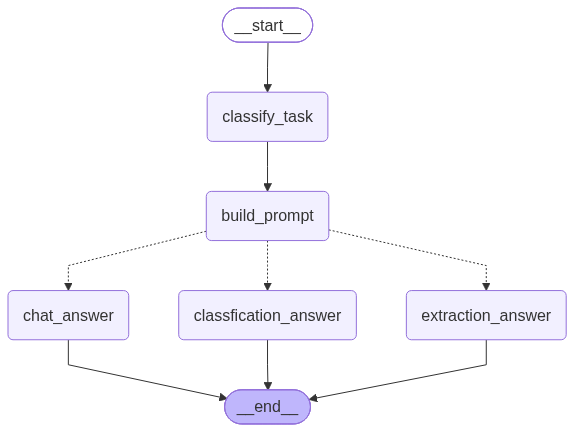

In [108]:
graph = StateGraph(ConditionalState)

graph.add_node("classify_task", classify_task)
graph.add_node("build_prompt", build_prompt)
graph.add_node("chat_answer", chat_answer)
graph.add_node("classfication_answer", classfication_answer)
graph.add_node("extraction_answer", extraction_answer)

graph.add_edge(START, "classify_task")
graph.add_edge("classify_task", "build_prompt")
graph.add_conditional_edges(
    "build_prompt",
    route_after_build_prompt,
    ["chat_answer", "classfication_answer", "extraction_answer"],
)
graph.add_edge("chat_answer", END)
graph.add_edge("classfication_answer", END)
graph.add_edge("extraction_answer", END)


app = graph.compile()
app

### Task 4

In [3]:
class TestPersistenceState(TypedDict):
    process_1: bool
    process_2: bool
    process_3: bool

In [4]:
def process_1(state: TestPersistenceState) -> dict:
    time.sleep(5)
    print("process 1 completed")
    return {"process_1": True}


def process_2(state: TestPersistenceState) -> dict:
    time.sleep(5)
    print("process 2 completed")
    return {"process_2": True}


def process_3(state: TestPersistenceState) -> dict:
    time.sleep(5)
    print("process 3 completed")
    return {"process_3": True}

In [16]:
graph = StateGraph(TestPersistenceState)

graph.add_node("process_1", process_1)
graph.add_node("process_2", process_2)
graph.add_node("process_3", process_3)

graph.add_edge(START, "process_1")
graph.add_edge("process_1", "process_2")
graph.add_edge("process_2", "process_3")
graph.add_edge("process_3", END)

In [20]:
with PostgresSaver.from_conn_string(DATABASE_CONNECTION_CHECKPOINT_URL) as checkpointer:
    checkpointer.setup()

    app = graph.compile(checkpointer=checkpointer, interrupt_before=["process_3"])

    config = {"configurable": {"thread_id": "test-1"}}

    result = app.invoke({"process_1": False, "process_2": False, "process_3": False}, config=config)

    print("PAUSED")
    print(result)

process 1 completed
process 2 completed
PAUSED
{'process_1': True, 'process_2': True, 'process_3': False}


In [21]:
with PostgresSaver.from_conn_string(DATABASE_CONNECTION_CHECKPOINT_URL) as checkpointer:
    checkpointer.setup()

    app = graph.compile(
        checkpointer=checkpointer,
    )

    config = {"configurable": {"thread_id": "test-1"}}

    result = app.invoke(None, config=config)

    print("RESUMED")
    print(result)

process 3 completed
RESUMED
{'process_1': True, 'process_2': True, 'process_3': True}


### Task 5

In [22]:
class Ticket(TypedDict, total=False):
    ticket_id: str
    customer: str
    amount: float
    reason: str
    approval: str
    result: str

In [ ]:
def prepare_refund(state: Ticket) -> dict:
    print("Prepare refund")

    return {"customer": "Test 1", "amount": 258.5, "reason": "for testing purpose"}


def human_approval(state: Ticket) -> dict:
    print("Human approval")

    decision = interrupt(
        {
            "type": "refund_approval",
            "ticked_id": state["ticket_id"],
            "customer": state["customer"],
            "amount": state["amount"],
            "reason": state["reason"],
            "message": "Approve this refund ?",
        }
    )

    return {
        "approval": decision,
    }


def route_result(state: Ticket) -> str:
    if state["approval"] == "approved":
        return "execute_refund"

    return "reject_refund"


def execute_refund(state: Ticket) -> dict:
    print("Execute refund")
    return {"result": f"Refund {state['amount']} to {state['customer']}"}


def reject_refund(state: Ticket) -> dict:
    print("Reject refund")

    return {"result": f"Refund rejected by human reviewer of {state['customer']}"}

In [24]:
graph = StateGraph(Ticket)

graph.add_node("prepare_refund", prepare_refund)
graph.add_node("human_approval", human_approval)
graph.add_node("execute_refund", execute_refund)
graph.add_node("reject_refund", reject_refund)

graph.add_edge(START, "prepare_refund")
graph.add_edge("prepare_refund", "human_approval")
graph.add_conditional_edges("human_approval", route_result, ["execute_refund", "reject_refund"])
graph.add_edge("execute_refund", END)
graph.add_edge("reject_refund", END)

checkpointer = InMemorySaver()
app = graph.compile(checkpointer=checkpointer)

In [25]:
config = {"configurable": {"thread_id": "refund-5001"}}

first = app.invoke({"ticket_id": "test-001"}, config=config, version="v2")

print("\nFIRST RESULT:")
print(first)

if first.interrupts:
    print("\nHUMAN REVIEW REQUEST:")
    print(first.interrupts[0].value)

Prepare refund
Human approval

FIRST RESULT:
GraphOutput(value={'ticket_id': 'test-001', 'customer': 'Test 1', 'amount': 258.5, 'reason': 'for testing purpose'}, interrupts=(Interrupt(value={'type': 'refund_approval', 'ticked_id': 'test-001', 'customer': 'Test 1', 'amount': 258.5, 'reason': 'for testing purpose', 'message': 'Approve this refund ?'}, id='f9139bca678ecdb32e2581d42d5ee4ee'),))

HUMAN REVIEW REQUEST:
{'type': 'refund_approval', 'ticked_id': 'test-001', 'customer': 'Test 1', 'amount': 258.5, 'reason': 'for testing purpose', 'message': 'Approve this refund ?'}


In [26]:
resume = app.invoke(Command(resume="rejected"), config=config, version="v2")

print(resume.value)

Human approval
Reject refund
{'ticket_id': 'test-001', 'customer': 'Test 1', 'amount': 258.5, 'reason': 'for testing purpose', 'approval': 'rejected', 'result': 'Refund rejected by human reviewer of Test 1'}


### Task 6

In [27]:
class TicketState(TypedDict, total=False):
    ticket_id: str
    customer: str
    analysis: str
    draft: str
    sent: bool

In [28]:
async def load_ticket(state: TicketState) -> dict:
    print("[node] load_ticket")
    await asyncio.sleep(1)

    return {"customer": "Acme Corp"}


async def analyze_ticker(state: TicketState) -> dict:
    print("[node] analyze_ticket")
    await asyncio.sleep(1)

    return {"analysis": "Duplicate billing is likely. Verify invoice/payment IDs."}


async def draft_response(state: TicketState) -> dict:
    print("[node] draft_response")
    await asyncio.sleep(1)

    return {
        "draft": (
            "Hi Acme Corp, we identified a possible duplicate charge. "
            "We are reviewing the payment records now."
        )
    }


async def send_response(state: TicketState) -> dict:
    print("[node] send_response")
    await asyncio.sleep(1)

    return {"sent": True}

In [29]:
graph = StateGraph(TicketState)

graph.add_node("load_ticket", load_ticket)
graph.add_node("analyze_ticker", analyze_ticker)
graph.add_node("draft_response", draft_response)
graph.add_node("send_response", send_response)

graph.set_entry_point("load_ticket")
graph.add_edge("load_ticket", "analyze_ticker")
graph.add_edge("analyze_ticker", "draft_response")
graph.add_edge("draft_response", "send_response")
graph.add_edge("send_response", END)

app = graph.compile()

In [31]:
initial_state = {"ticket_id": "test-1002"}

async for chunk in app.astream(initial_state, stream_mode="updates", version="v2"):
    print("chunk:\n")
    print(chunk, "=" * 50)
    if chunk["type"] != "updates":
        continue

    print("\nSTREAM EVENT:")
    print(chunk["data"])

[node] load_ticket
chunk:

{'type': 'updates', 'ns': (), 'data': {'load_ticket': {'customer': 'Acme Corp'}}} ==================================================

STREAM EVENT:
{'load_ticket': {'customer': 'Acme Corp'}}
[node] analyze_ticket
chunk:

{'type': 'updates', 'ns': (), 'data': {'analyze_ticker': {'analysis': 'Duplicate billing is likely. Verify invoice/payment IDs.'}}} ==================================================

STREAM EVENT:
{'analyze_ticker': {'analysis': 'Duplicate billing is likely. Verify invoice/payment IDs.'}}
[node] draft_response
chunk:

{'type': 'updates', 'ns': (), 'data': {'draft_response': {'draft': 'Hi Acme Corp, we identified a possible duplicate charge. We are reviewing the payment records now.'}}} ==================================================

STREAM EVENT:
{'draft_response': {'draft': 'Hi Acme Corp, we identified a possible duplicate charge. We are reviewing the payment records now.'}}
[node] send_response
chunk:

{'type': 'updates', 'ns': (), 'da

### Task 7

### Module 11 — LCEL vs LangGraph

### Same Workflow

User Query → Retrieve Documents → Generate Answer → Final Answer

### Module 10 — LCEL

LCEL is best for simple, linear workflows.

```python
chain = retriever | prompt | llm | parser
```

### Features

- Simple and sequential
- Easy to build
- Good for fixed workflows
- Minimal state management

### Module 11 — LangGraph

LangGraph represents the workflow as connected nodes.

```text
START
  ↓
Retrieve
  ↓
Grade
  ├── Good → Generate → END
  └── Bad  → Retrieve (retry)
```

### Features

- Shared state
- Conditional routing
- Loops and retries
- Checkpointing
- Human-in-the-loop
- Pause and resume

### What Was Genuinely Necessary?

| Feature | LCEL | LangGraph | Necessary? |
|---|---|---|---|
| Simple retrieval → generation | Yes | Yes | No |
| Passing data between steps | Yes | Yes | No |
| Retry / loops | Possible, but awkward | Yes | Yes |
| Conditional routing | Limited | Yes | Yes |
| Human approval | Not natural | Yes | Yes |
| Persistent checkpoints | Not its main model | Yes | Yes |

### Conclusion

For a simple linear RAG workflow, **LCEL is enough**.

LangGraph becomes genuinely useful when the workflow needs **loops, branching, human approval, or persistent state/checkpoints**.

Therefore, LangGraph was necessary for the **stateful and non-linear parts**, not merely because the code looked different.